# Pre-alignment, rasterization and S-LDDMM (MERFISH mouse brain)

This notebook aligns the MERFISH S2R3 query sample to the fixed S2R2 reference sample. It starts from the AnnData produced by the joint-clustering notebook and follows the cross-sample method described in the paper:

1. automatic weighted shared-cluster-centroid pre-alignment, with an optional interactive manual similarity transform;
2. rasterization into shared-cluster composition and tissue-density fields;
3. shooting-based LDDMM refinement; and
4. transformation of the original query cells.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Installation and input

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
```

By default this notebook reads `tutorials/cross_sample/output/merfish_S2_joint_clustered.h5ad`. To use another clustered AnnData file:

```bash
export SPALIGNDE_CLUSTERED_H5AD=/path/to/clustered_data.h5ad
```

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "output"
default_path = OUTPUT_DIR / "merfish_S2_joint_clustered.h5ad"
clustered_path = Path(os.environ.get("SPALIGNDE_CLUSTERED_H5AD", default_path)).expanduser().resolve()

adata = spAlignDE.load_cross_sample_data(clustered_path)
spAlignDE.validate_cross_sample_anndata(adata)

QUERY = "S2R3"
REFERENCE = "S2R2"
print("Loaded clustered AnnData")
print(adata)
print(adata.obs["sample_id"].value_counts().sort_index())

Loaded clustered AnnData
AnnData object with n_obs × n_vars = 170130 × 649
    obs: 'x', 'y', 'sample_id', 'orig_cell_id', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'cell_id', 'cluster_raw', 'cluster_refined', 'cluster'
    uns: 'spAlignDE'
    obsm: 'spatial'
sample_id
S2R2    84172
S2R3    85958
Name: count, dtype: int64


## Global similarity pre-alignment

For each shared spatial structure, spAlignDE calculates its query and reference centroids. A weighted Procrustes fit estimates scale, rotation and translation, using the smaller structure size in the two samples as its default weight. Reflection is disabled. This automatic result also initializes the optional manual controls below.

In [2]:
automatic_prealignment = spAlignDE.prealign_cross_sample(
    adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=spAlignDE.PrealignmentConfig(
        allow_scaling=True,
        allow_reflection=False,
        use_cluster_size_weights=True,
        min_cluster_size=10,
    ),
)

print("Pre-alignment parameters:")
for key in ("scale", "theta_deg", "translation_x", "translation_y", "n_shared_clusters", "weighted_centroid_rmse"):
    print(f"  {key}: {automatic_prealignment.params[key]}")
automatic_prealignment.centroid_matches.head()

Using cluster-correspondence prealign with 26 shared clusters
{
  "scale": 0.9900468544887884,
  "theta_deg": -50.36315201078973,
  "translation_x": -1188.418712628647,
  "translation_y": 6795.073749946745,
  "det_R": 1.0,
  "R": [
    [
      0.6379193893962879,
      0.7701031441516566
    ],
    [
      -0.7701031441516566,
      0.6379193893962881
    ]
  ],
  "t": [
    -1188.418712628647,
    6795.073749946745
  ],
  "prealign_method": "shared_cluster_weighted_procrustes",
  "transform_convention": "aligned = scale * source @ R.T + t",
  "source_sample": "S2R3",
  "target_sample": "S2R2",
  "cluster_col": "cluster",
  "n_shared_clusters": 26,
  "weighted_centroid_rmse": 439.382011889676,
  "unweighted_centroid_rmse": 653.5789556328123,
  "allow_scaling": true,
  "allow_reflection": false,
  "weight_mode": "min_size",
  "min_cluster_size": 10
}


Pre-alignment parameters:
  scale: 0.9900468544887884
  theta_deg: -50.36315201078973
  translation_x: -1188.418712628647
  translation_y: 6795.073749946745
  n_shared_clusters: 26
  weighted_centroid_rmse: 439.382011889676


,cluster,source_centroid_x,source_centroid_y,target_centroid_x,target_centroid_y,source_n_cells,target_n_cells,weight,source_aligned_centroid_x,source_aligned_centroid_y,residual_distance
0,0,5220.093973,1684.555549,3639.839798,3506.334559,7713,7733,7713.0,3392.805974,3878.989612,447.098981
1,1,4927.675079,5574.190117,6213.819477,6745.151030,7335,6812,6812.0,6173.728910,6558.517780,190.890606
2,10,5369.971257,4082.850845,5193.512193,5689.674646,3390,3725,3390.0,5316.015921,5279.409010,428.164753
3,11,5141.919672,3444.753850,4701.073057,4804.237797,4494,4124,4124.0,4685.475840,5050.281275,246.537352
4,12,5033.142250,2119.960671,3946.356659,3842.737027,3021,3023,3021.0,3606.702354,4296.517596,566.817301


### Optional interactive manual pre-alignment

Automatic shared-cluster matching is the default. For samples with partial tissue coverage, unusual orientation, or imperfect cluster correspondence, set `PREALIGNMENT_MODE = "manual"` and adjust `scale`, `theta`, `tx`, and `ty` below. The convention is `aligned = scale * query @ R.T + t`, with rotation in degrees. The sliders start from the automatic Procrustes solution.

The complete slider panel is provided by `spAlignDE.interactive_manual_prealignment`, rather than implemented inside this notebook. After changing the sliders, rerun the **Select and save the pre-alignment** cell and every downstream cell. For reproducible batch execution, exact values may instead be supplied through `SPALIGNDE_MANUAL_SCALE`, `SPALIGNDE_MANUAL_THETA_DEG`, `SPALIGNDE_MANUAL_TX`, and `SPALIGNDE_MANUAL_TY`. The selected transform is recorded in the output AnnData and a JSON file.

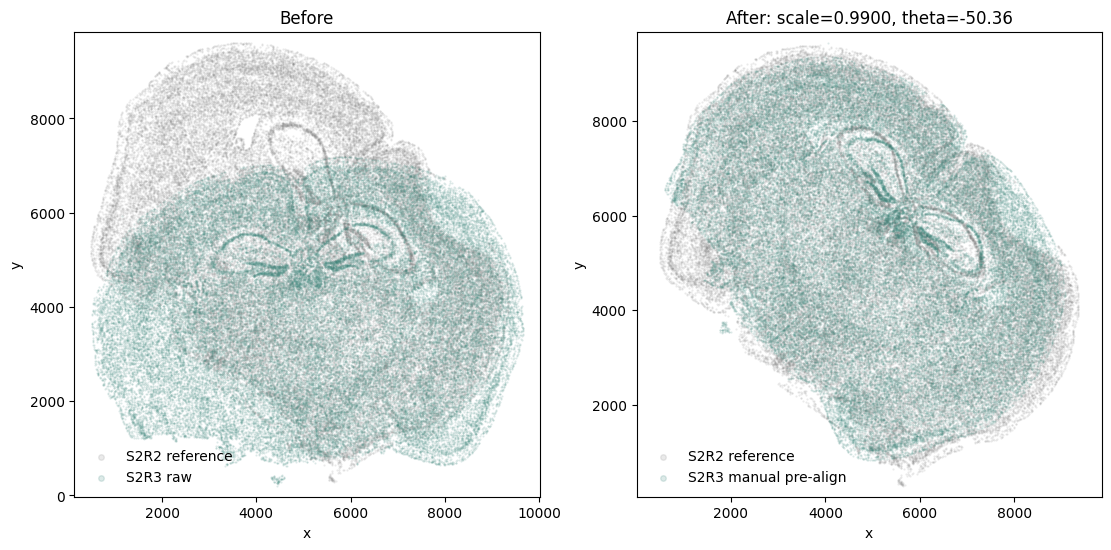

Selected pre-alignment mode: automatic


In [3]:
# Change to "manual" to use the slider/direct values downstream.
PREALIGNMENT_MODE = os.environ.get("SPALIGNDE_PREALIGNMENT_MODE", "automatic").strip().lower()
if PREALIGNMENT_MODE not in {"automatic", "manual"}:
    raise ValueError("SPALIGNDE_PREALIGNMENT_MODE must be 'automatic' or 'manual'")

auto_params = automatic_prealignment.params
initial_manual_config = spAlignDE.ManualPrealignmentConfig(
    scale=float(os.environ.get("SPALIGNDE_MANUAL_SCALE", auto_params["scale"])),
    theta_deg=float(os.environ.get("SPALIGNDE_MANUAL_THETA_DEG", auto_params["theta_deg"])),
    translation_x=float(os.environ.get("SPALIGNDE_MANUAL_TX", auto_params["translation_x"])),
    translation_y=float(os.environ.get("SPALIGNDE_MANUAL_TY", auto_params["translation_y"])),
)

manual_ui = None
ENABLE_INTERACTIVE_PREVIEW = os.environ.get("SPALIGNDE_ENABLE_WIDGETS", "1") != "0"
if ENABLE_INTERACTIVE_PREVIEW:
    try:
        manual_ui = spAlignDE.interactive_manual_prealignment(
            adata,
            query_sample=QUERY,
            reference_sample=REFERENCE,
            initial_config=initial_manual_config,
            max_points=50_000,
            random_state=1_000,
        )
    except ImportError as exc:
        print(exc)
        print("Showing a static preview instead.")

if manual_ui is None:
    static_manual_preview, _ = spAlignDE.plot_manual_prealignment_preview(
        adata,
        query_sample=QUERY,
        reference_sample=REFERENCE,
        config=initial_manual_config,
        max_points=50_000,
        random_state=1_000,
    )
    display(static_manual_preview)
    plt.close(static_manual_preview)

print("Selected pre-alignment mode:", PREALIGNMENT_MODE)

#### Select and save the pre-alignment

In manual mode, `manual_ui.apply()` reads the current slider values and returns the same `PrealignmentResult` as the non-interactive API. If widgets are disabled, this cell uses the exact environment-derived `initial_manual_config`. The chosen transform becomes the input to rasterization and S-LDDMM.

In [4]:
if PREALIGNMENT_MODE == "manual":
    if manual_ui is not None:
        prealignment = manual_ui.apply()
    else:
        prealignment = spAlignDE.prealign_cross_sample_manual(
            adata,
            query_sample=QUERY,
            reference_sample=REFERENCE,
            config=initial_manual_config,
        )
else:
    prealignment = automatic_prealignment

prealignment_path = OUTPUT_DIR / f"prealignment_{QUERY}_to_{REFERENCE}.json"
with prealignment_path.open("w", encoding="utf-8") as handle:
    json.dump(prealignment.params, handle, indent=2)

print("Using:", prealignment.params["prealign_method"])
print("Saved:", prealignment_path.relative_to(PROJECT_ROOT))
for key in ("scale", "theta_deg", "translation_x", "translation_y"):
    print(f"  {key}: {prealignment.params[key]}")

Using: shared_cluster_weighted_procrustes
Saved: tutorials/cross_sample/output/prealignment_S2R3_to_S2R2.json
  scale: 0.9900468544887884
  theta_deg: -50.36315201078973
  translation_x: -1188.418712628647
  translation_y: 6795.073749946745


### Pre-alignment visual check

The left panel shows the raw query/reference point clouds and matched shared-cluster centroids. The right panel shows the same cluster-centroid correspondences after the selected automatic or manual similarity transformation. Inspect this figure before rasterization.

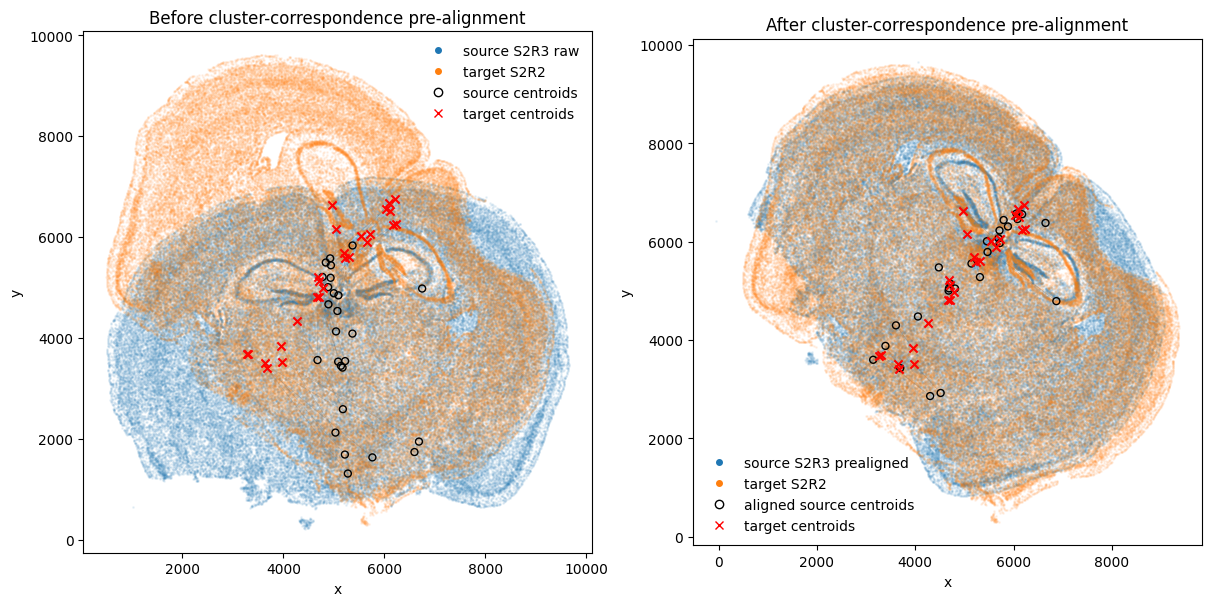

In [5]:
sample = prealignment.adata.obs["sample_id"].astype(str)
query_mask = sample.eq(QUERY).to_numpy()
reference_mask = sample.eq(REFERENCE).to_numpy()
spAlignDE.plot_prealignment_result(prealignment)

## Convert cells to continuous pseudo-images

Only cluster identities present in both samples define composition channels. For shared structure $r$, the smoothed count field is divided by the total smoothed shared-structure density to obtain its local composition. A pooled, log-scaled tissue-density channel is appended so that empty and densely sampled regions remain distinguishable.

Shared cluster channels: 26
Pseudo-image shape: (27, 331, 331)
Shared grid: 331 x 331


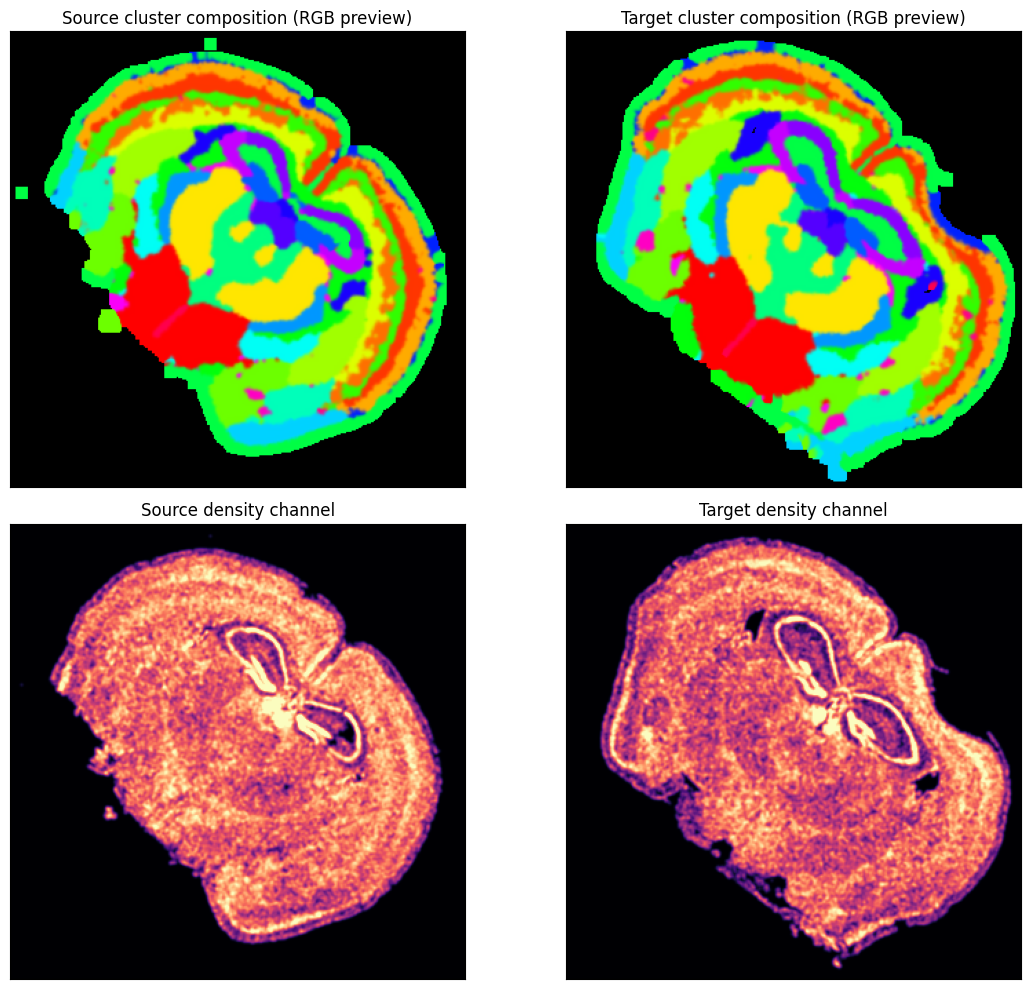

In [6]:
fields = spAlignDE.rasterize_cross_sample(
    prealignment.adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=spAlignDE.RasterizationConfig(
        grid_spacing=30,
        grid_expand=1.05,
        blur_sigma=1,
        cluster_weight=1,
        density_weight=1,
    ),
)

print("Shared cluster channels:", len(fields.shared_clusters))
print("Pseudo-image shape:", fields.query_image.shape)
print("Shared grid:", len(fields.grid_y), "x", len(fields.grid_x))
spAlignDE.plot_rasterized_fields(fields)

## Shooting-based LDDMM refinement

S-LDDMM optimizes one initial momentum field and propagates the corresponding geodesic trajectory. The query and reference pseudo-images use identical channel order. The learned transformation is applied back to all original S2R3 cells; rasterization is used only to estimate the transformation.

In [7]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
slddmm_config = spAlignDE.SLDDMMConfig(
    kernel_scale=300,
    kernel_power=2,
    velocity_expand=2,
    time_steps=3,
    velocity_grid_spacing=100,
    iterations=500,
    momentum_lr=2000,
    minimum_momentum_lr=2000,
    restore_best_checkpoint=False,
    restore_best_checkpoint=False,
    restore_best_checkpoint=False,
    restore_best_checkpoint=False,
    dtype="float32",
)

result = spAlignDE.run_slddmm_alignment(
    prealignment.adata,
    fields,
    config=slddmm_config,
    device=device,
    prealignment=prealignment,
    verbose=True,
    print_every=100,
)

print("Alignment summary:")
for key, value in result.metrics.items():
    print(f"  {key}: {value}")

[LDDMM] start: niter=500, nt=3, device=cuda:0, I_shape=(27, 331, 331), J_shape=(27, 331, 331)


[LDDMM] iter 1/500 E=9.775127e+03 EM=9.775127e+03 ER=0.000000e+00


[LDDMM] iter 101/500 E=1.061171e+04 EM=1.060033e+04 ER=1.137895e+01


[LDDMM] iter 201/500 E=9.147922e+03 EM=9.130227e+03 ER=1.769574e+01


[LDDMM] iter 301/500 E=8.574206e+03 EM=8.552621e+03 ER=2.158465e+01


[LDDMM] iter 401/500 E=8.316945e+03 EM=8.292833e+03 ER=2.411182e+01


[LDDMM] iter 500/500 E=8.139589e+03 EM=8.113503e+03 ER=2.608625e+01
[LDDMM] done in 5.8s. finalE=8.139589e+03


Alignment summary:
  nearest_label_agreement_prealigned: 0.4340608204006608
  nearest_label_agreement_aligned: 0.7835919867842435
  nearest_label_agreement_gain: 0.34953116638358267
  elapsed_seconds: 5.805899620056152
  n_shared_clusters: 26
  device: cuda:0


### How to adapt rasterization and S-LDDMM parameters

First confirm that the global pre-alignment is anatomically plausible and that
the rasterized shared structures overlap. S-LDDMM should refine an already
credible initialization, not repair a wrong rotation, scale, reflection or
cluster correspondence.

- `grid_spacing` is the structural-image resolution. Smaller values preserve
  detail but increase memory and sensitivity to sparse sampling.
- `blur_sigma` is measured in raster pixels. Increase it for fragmented sparse
  fields; decrease it if adjacent thin structures merge.
- `density_weight` is useful when sampling density describes tissue shape. It
  can be reduced or set to zero for approximately regular spot grids.
- `kernel_scale` is legacy `a`. Increasing it makes deformation smoother and
  more global; decreasing it permits more local bending and raises overfitting
  risk.
- `velocity_grid_spacing` is legacy `grid_step`. Decreasing it creates a denser
  velocity field with more memory/runtime and local flexibility; increasing it
  produces a coarser, more regularized field. Tune it together with `a`.
- `time_steps` (`nt`) controls integration accuracy rather than deformation
  amplitude. `iterations` (`niter`) controls optimization duration.
- Increase `momentum_lr` (`lrM`) only when energy decreases stably but too
  slowly; reduce it if energy oscillates, becomes non-finite or the warp is
  implausibly local.

All distance-valued settings use the coordinates passed to this stage. Do not
copy `a`, `grid_step`, raster spacing or translations between differently
scaled datasets without rescaling and rechecking the velocity-grid dimensions.

### Alignment visual comparisons

The first figure compares query/reference overlap before and after S-LDDMM without cluster colors, emphasizing tissue geometry. The second repeats the comparison with one shared color for each joint-cluster identity, making local structural correspondence visible.

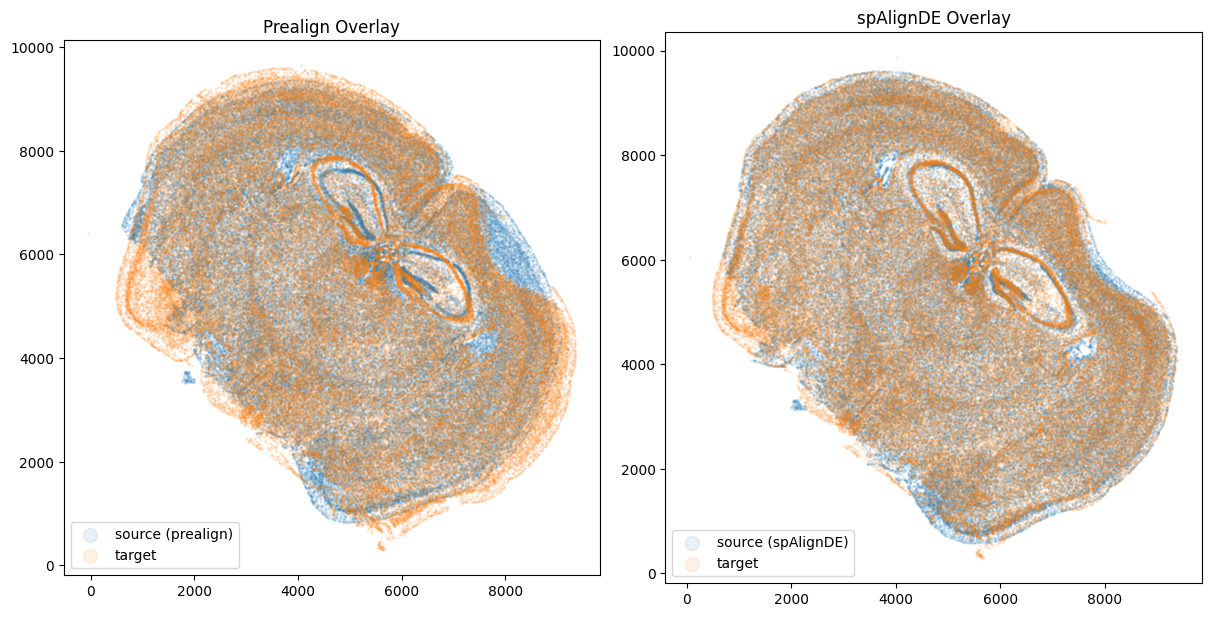

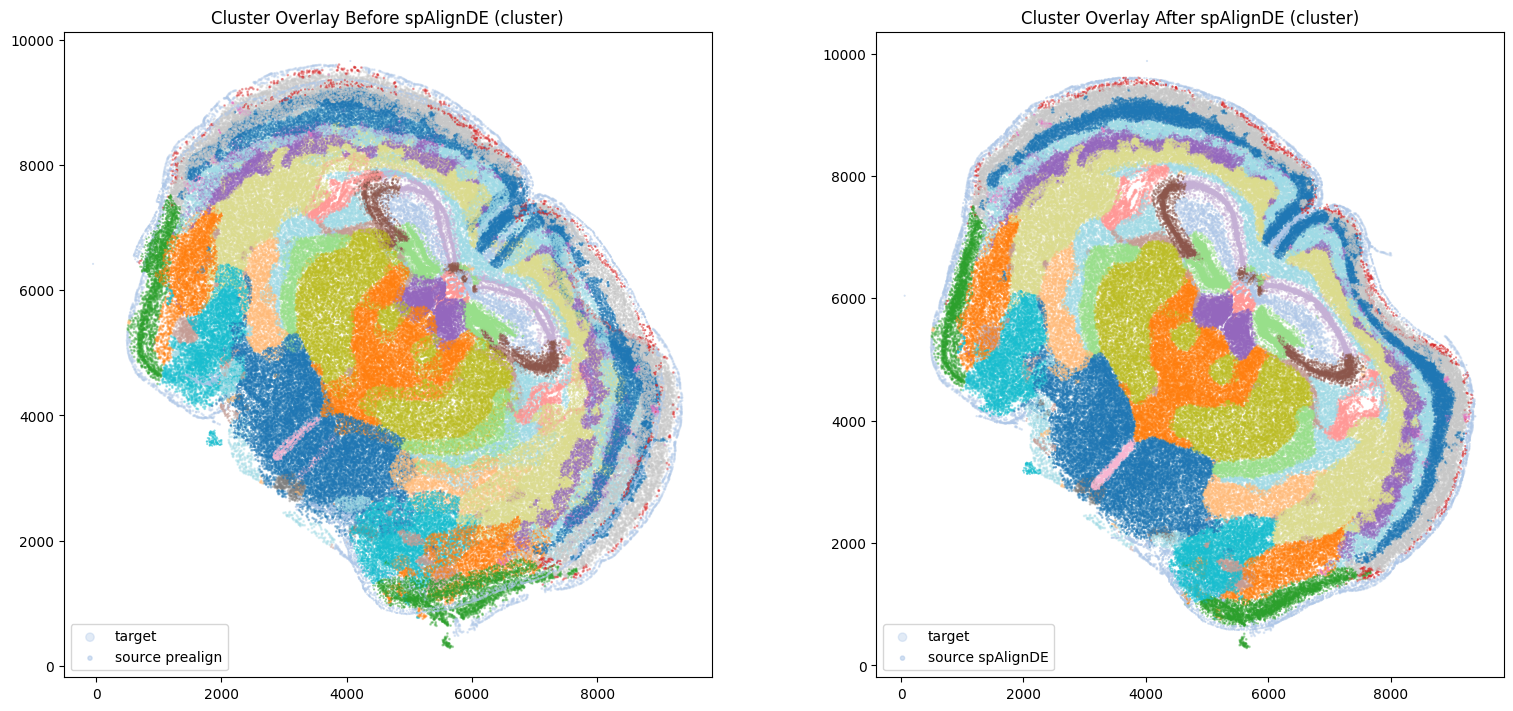

,cluster,n_cells,prealign_match_rate,lddmm_match_rate,prealign_mean_nn_dist,lddmm_mean_nn_dist,match_rate_gain
0,0,7713,0.782316,0.916245,12.016268,11.666183,0.133930
1,1,7335,0.228085,0.787048,21.744121,9.728283,0.558964
2,10,3390,0.375221,0.753097,42.563807,28.339046,0.377876
3,11,4494,0.651313,0.882733,11.590610,11.092575,0.231420
4,12,3021,0.518702,0.797749,12.247111,12.817340,0.279047
5,13,2401,0.502291,0.795085,13.097442,13.345873,0.292795
6,14,2307,0.221066,0.856090,17.140789,14.656765,0.635024
7,15,2191,0.441807,0.911456,12.273069,12.008301,0.469649
8,16,2177,0.662379,0.849793,13.215533,10.744540,0.187414
9,17,595,0.073950,0.337815,51.959610,23.368177,0.263866


In [8]:
# Comparison 1: query/reference overlap without cluster colors.
spAlignDE.plot_alignment_result(result)

# Comparison 2: the same prealign-versus-S-LDDMM comparison with
# one shared color palette for query and reference cluster identities.
spAlignDE.plot_cluster_alignment_result(result)

result.cluster_performance.sort_values("cluster").head(10)

## Save the aligned AnnData

The original coordinate matrix remains in `adata.obsm["spatial"]`. The package adds four standardized columns to `adata.obs`: `x_prealigned`, `y_prealigned`, `x_aligned`, and `y_aligned`. For the fixed S2R2 reference, these values equal the original coordinates.

In [9]:
aligned_path = OUTPUT_DIR / "merfish_S2R3_to_S2R2_aligned.h5ad"
result.adata.write_h5ad(aligned_path)

output_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
print("Saved:", aligned_path.relative_to(PROJECT_ROOT))
print(result.adata.obs.loc[result.adata.obs["sample_id"].astype(str).eq(QUERY), output_columns].head())

reference_output = result.adata.obs.loc[
    result.adata.obs["sample_id"].astype(str).eq(REFERENCE), output_columns
].to_numpy()
reference_raw = np.asarray(result.adata.obsm["spatial"])[reference_mask]
assert np.allclose(reference_output[:, :2], reference_raw)
assert np.allclose(reference_output[:, 2:], reference_raw)
print("Reference coordinates verified unchanged.")

Saved: tutorials/cross_sample/output/merfish_S2R3_to_S2R2_aligned.h5ad
          x_prealigned  y_prealigned    x_aligned    y_aligned
spot_uid                                                      
S2R3_1     1234.895643   8008.044787  1177.703613  8089.041504
S2R3_2     1295.467219   8085.356880  1230.164917  8178.536133
S2R3_3     1273.110424   8089.885790  1208.180176  8181.753418
S2R3_4     1282.658574   8105.848073  1216.345947  8199.715820
S2R3_5     1244.795940   8028.526606  1185.510986  8112.472168
Reference coordinates verified unchanged.
